In [24]:
# Dikra Ardahi

Classe prédite = chien


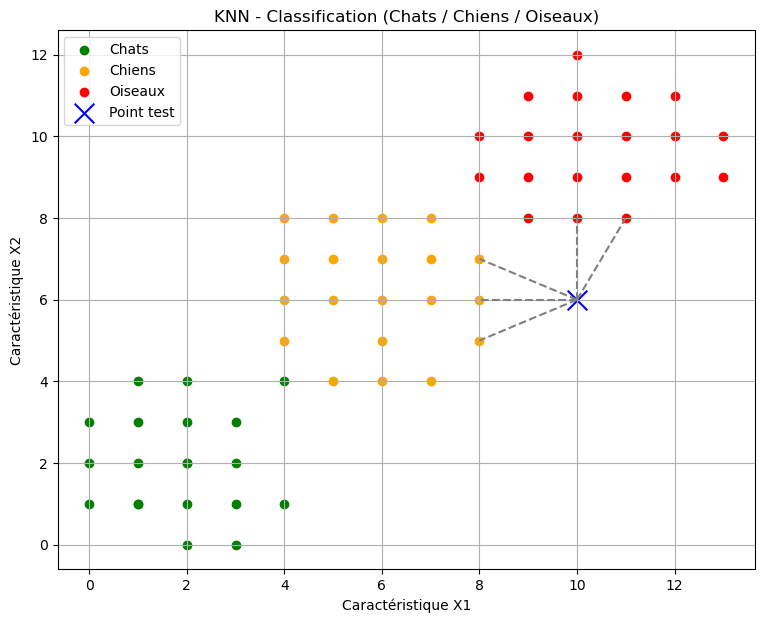

In [25]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================
# 1. DATASET
# ============================================

# X0 : classe 0 (Chats)
# chaque point = (X1, X2)

X0 = np.array([
    [1,2],[2,1],[2,2],[3,1],[3,2],
    [1,3],[2,3],[3,3],[1,1],[2,0],
    [0,2],[0,1],[1,1],[2,2],[3,0],
    [1,4],[2,4],[4,4],[4,1],[0,3]
])

# X1 : classe 1 (Chiens)

X1 = np.array([
    [4,8],[6,5],[5,6],[6,6],[4,7],
    [7,6],[6,7],[5,7],[8,6],[6,8],
    [7,7],[5,8],[8,5],[4,6],[6,4],
    [7,4],[4,5],[5,4],[8,7],[7,8]
])

# X2 : classe 2 (Oiseaux)

X2 = np.array([
    [9,9],[10,8],[10,10],[11,9],[12,10],
    [9,10],[10,11],[11,10],[12,9],[9,11],
    [8,10],[10,9],[11,11],[12,11],[8,9],
    [13,10],[10,12],[11,8],[9,8],[13,9]
])

# ============================================
# 2. FUSION DES DONNÉES
# ============================================

# X : dataset final (toutes les classes ensemble)
X = np.vstack((X0, X1, X2))

# y : labels des classes
# 0 = Chats
# 1 = Chiens
# 2 = Oiseaux
y = np.array([0]*20 + [1]*20 + [2]*20)

# dictionnaire pour afficher les noms
classe = {0:"chat", 1:"chien", 2:"oiseau"}


# ============================================
# 3. FONCTION KNN
# ============================================

def knn(X, y, x_new, k=5):

    # distances : liste vide pour stocker les distances
    distances = []

    # boucle sur tous les points du dataset
    for i in range(len(X)):

        # calcul de la distance euclidienne
        # sqrt((x1-x2)^2 + (y1-y2)^2)
        d = np.sqrt((X[i][0]-x_new[0])**2 + (X[i][1]-x_new[1])**2)

        # on stocke :
        # (distance, classe, point)
        distances.append((d, y[i], X[i]))

    # tri des distances du plus proche au plus loin
    distances.sort(key=lambda x: x[0])

    # on prend les k plus proches voisins
    neighbors = distances[:k]

    # on récupère seulement les classes des voisins
    classes = [c for _, c, _ in neighbors]

    # vote majoritaire :
    # la classe la plus fréquente gagne
    prediction = max(set(classes), key=classes.count)

    return prediction, neighbors


# ============================================
# 4. TEST
# ============================================

# x_test : nouveau point à classifier
x_test = np.array([10,6])

# application de KNN
prediction, neighbors = knn(X, y, x_test, k=5)

# affichage du résultat
print("Classe prédite =", classe[prediction])


# ============================================
# 5. VISUALISATION
# ============================================

plt.figure(figsize=(9,7))

# affichage classe 0 (Chats)
plt.scatter(X[y==0][:,0], X[y==0][:,1],
            color="green", label="Chats")

# affichage classe 1 (Chiens)
plt.scatter(X[y==1][:,0], X[y==1][:,1],
            color="orange", label="Chiens")

# affichage classe 2 (Oiseaux)
plt.scatter(X[y==2][:,0], X[y==2][:,1],
            color="red", label="Oiseaux")

# point test (nouvelle donnée)
plt.scatter(x_test[0], x_test[1],
            color="blue", marker="x", s=200, label="Point test")


# ============================================
# 6. VOISINS PROCHES
# ============================================

# chaque voisin influence la décision finale
for d, c, point in neighbors:

    # ligne entre test et voisin
    plt.plot([x_test[0], point[0]],
             [x_test[1], point[1]],
             color="gray", linestyle="--")


# ============================================
# 7. STYLE FINAL
# ============================================

plt.title("KNN - Classification (Chats / Chiens / Oiseaux)")
plt.xlabel("Caractéristique X1")
plt.ylabel("Caractéristique X2")
plt.legend()
plt.grid()

plt.show()

Decision value = 0.20900000000022123
Classe = Chiens (+1)


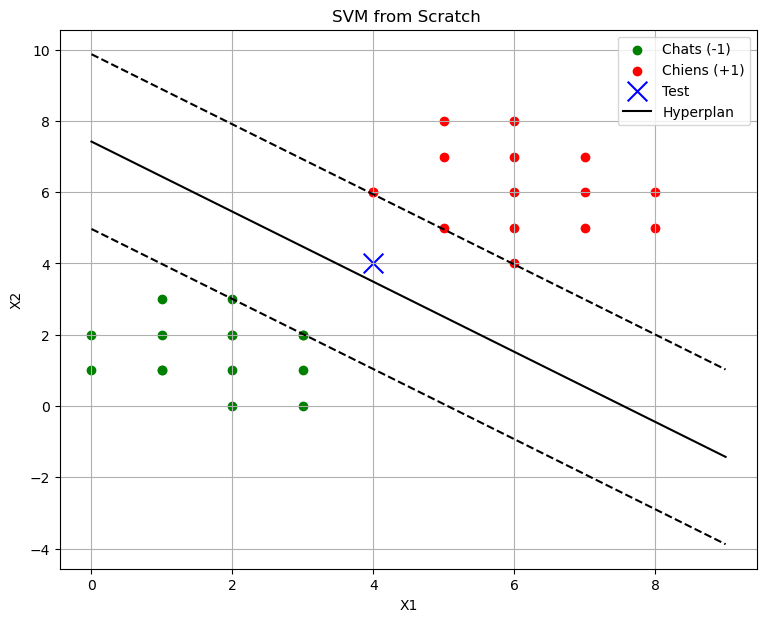

In [26]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================
# 1. IMPORTATION DES LIBRAIRIES
# ============================================

# numpy : pour faire les calculs (vecteurs, matrices)
# matplotlib : pour afficher les graphiques


# ============================================
# 2. CRÉATION DU DATASET
# ============================================

# X0 : classe -1 (Chats)
# ce sont des points regroupés en bas/gauche
X0 = np.array([
    [1,2],[2,1],[2,2],[3,1],[3,2],
    [1,3],[2,3],[3,2],[1,1],[2,0],
    [0,2],[0,1],[1,1],[2,2],[3,0]
])

# X1 : classe +1 (Chiens)
# points plus au centre/droite

X1 = np.array([
    [5,5],[6,5],[4,6],[6,6],[7,5],
    [7,6],[6,7],[5,7],[8,6],[6,8],
    [7,7],[5,8],[8,5],[4,6],[6,4]
])

# X : on regroupe toutes les données ensemble
# X devient la dataset finale
X = np.vstack((X0, X1))

# y : labels des classes
# -1 = Chats
# +1 = Chiens
y = np.array([-1]*15 + [1]*15)


# ============================================
# 3. MODÈLE SVM FROM SCRATCH
# ============================================

class SVM:

    # constructeur du modèle
    def __init__(self, lr=0.001, epochs=2000):

        # lr : learning rate (vitesse d'apprentissage)
        self.lr = lr

        # epochs : nombre d'itérations
        self.epochs = epochs


    # ========================================
    # APPRENTISSAGE DU MODÈLE
    # ========================================
    def fit(self, X, y):

        # w : poids (coefficients du modèle)
        # b : biais (intercept)
        self.w = np.zeros(X.shape[1])  # initialisation à 0
        self.b = 0

        # boucle d'apprentissage
        for _ in range(self.epochs):

            # parcourir tous les points
            for i in range(len(X)):

                # x_i : point actuel
                # y_i : label du point
                x_i = X[i]
                y_i = y[i]

                # formule SVM :
                # y_i * (w.x + b)
                # si < 1 => erreur ou dans la marge
                condition = y_i * (np.dot(x_i, self.w) + self.b)

                # si mauvaise classification
                if condition < 1:

                    # mise à jour des poids
                    self.w = self.w + self.lr * (y_i * x_i)

                    # mise à jour du biais
                    self.b = self.b + self.lr * y_i


    # ========================================
    # PRÉDICTION
    # ========================================
    def decision(self, X):

        # calcul w.x + b
        return np.dot(X, self.w) + self.b


# ============================================
# 4. ENTRAÎNEMENT DU MODÈLE
# ============================================

# création du modèle SVM
model = SVM()

# apprentissage sur les données X et labels y
model.fit(X, y)


# ============================================
# 5. TEST
# ============================================

# nouveau point à classifier
x_test = np.array([4,4])

# calcul de la décision
result = model.decision(x_test)

# affichage du score
print("Decision value =", result)

# interprétation du résultat
if result > 0:
    print("Classe = Chiens (+1)")
else:
    print("Classe = Chats (-1)")


# ============================================
# 6. VISUALISATION
# ============================================

plt.figure(figsize=(9,7))

# afficher classe -1 (Chats)
plt.scatter(X0[:,0], X0[:,1],
            color="green", label="Chats (-1)")

# afficher classe +1 (Chiens)
plt.scatter(X1[:,0], X1[:,1],
            color="red", label="Chiens (+1)")

# afficher point test
plt.scatter(x_test[0], x_test[1],
            color="blue", marker="x", s=200, label="Test")


# ============================================
# 7. HYPERPLANE + MARGES (PRINCIPE SVM)
# ============================================

# création de valeurs X pour tracer la ligne
x_line = np.linspace(0, 9, 200)

# vérifier division par zéro
if model.w[1] != 0:

    # hyperplan principal : w.x + b = 0
    y_line = -(model.w[0]*x_line + model.b) / model.w[1]

    # marge positive : w.x + b = +1
    y_plus = -(model.w[0]*x_line + model.b - 1) / model.w[1]

    # marge négative : w.x + b = -1
    y_minus = -(model.w[0]*x_line + model.b + 1) / model.w[1]

    # affichage hyperplan
    plt.plot(x_line, y_line, "k-", label="Hyperplan")

    # affichage marges
    plt.plot(x_line, y_plus, "k--")
    plt.plot(x_line, y_minus, "k--")


# ============================================
# 8. STYLE FINAL
# ============================================

plt.title("SVM from Scratch ")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid()

plt.show()